# Image Deblurring and Ill-Conditioned Optimization

Project 2: Ill-Conditioned Optimization

This report studies image deblurring as an ill-conditioned inverse problem. It follows the assignment's six report sections and uses diagnostics D1-D4 to connect the blur spectrum, intrinsic conditioning, optimizer slowdown, and a Tikhonov remedy.

To reproduce the results, select the project's Python environment with NumPy, SciPy, Matplotlib, and ipykernel installed, then use **Restart Kernel and Run All**. Run every cell in order; later experiments reuse the earlier operator, observation, and baseline histories. No external image or dataset is needed. Fixed seeds make the synthetic data repeatable; library versions and floating-point arithmetic can cause tiny numerical differences.

Assignment: [Project 2 report requirements and diagnostic protocol](https://designinformaticslab.github.io/DesignOptimization2025/project2.html#report-requirements).


## 1. Problem identification and motivation

A mechanical engineer inspecting a manufactured part may need to identify a boundary or a small surface feature in an out-of-focus camera image. Camera operators and inspection engineers face a practical choice: how much sharpening to apply before measurement noise becomes mistaken for physical detail. Blur hides edges and narrow features; aggressive inversion can turn small sensor errors into large image artifacts.

We model this as recovering a sharp grayscale image from a known blur and a noisy observation. The square, disk, and thin bars are a controlled substitute for part boundaries and fine features. This synthetic example lets us separate three questions: why blur makes the optimization landscape ill-conditioned, how that affects ordinary gradient descent, and how regularization stabilizes reconstruction. It is a demonstration of the mechanism, rather than a validated inspection system.


## 2. Formulation

Let $n=128$ be the number of pixels along each image side and $N=n^2=16{,}384$ the total number of unknown intensities. We stack image rows into a vector. An array Frobenius norm therefore equals the Euclidean norm of its vectorization.

| Symbol / notebook name | Meaning and dimensions | Units / type |
| --- | --- | --- |
| $X$, $x=\operatorname{vec}(X)$ | Unknown image: $X\in\mathbb R^{128\times128}$, $x\in\mathbb R^{16384}$ | Continuous normalized grayscale intensity; dimensionless |
| $X_{\mathrm{true}}$, `sharp_image` | Known reference used to generate and evaluate this synthetic example | Same dimensions and units as $X$; fixed data, not an optimization variable |
| $Y$, $y=\operatorname{vec}(Y)$, `noisy_image` | Fixed blurred, noisy observation, with $Y\in\mathbb R^{128\times128}$ and $y\in\mathbb R^{16384}$ | Normalized intensity |
| $E$, $e=\operatorname{vec}(E)$, `noise` | Additive noise of the same image/vector dimensions | Independent Gaussian samples, mean 0, standard deviation $\eta=0.03$ in normalized intensity units |
| $\sigma$, `blur_sigma` | Gaussian blur width; 2 pixels for the main reconstruction | Pixels; known experiment parameter, not optimized |
| $B_\sigma$ | One-axis blur matrix, $128\times128$ | Dimensionless, normalized convolution weights |
| $A_\sigma=B_\sigma\otimes B_\sigma$ | Two-axis blur matrix, $16384\times16384$ | Dimensionless linear operator; applied without assembling the full matrix |
| $H=A_\sigma^T A_\sigma$, $D$, $H_J$, $I_N$ | Hessian, its diagonal, scaled Hessian, identity: all $16384\times16384$ | Curvature / scaling operators |
| $\lambda$, `d4_lambda` | Tikhonov penalty coefficient, 0.01 in D4 | Dimensionless in this normalized model; fixed, not optimized |

The observation model is

$$y=A_\sigma x_{\mathrm{true}}+e, \qquad E_{ij}\sim\mathcal N(0,\eta^2), \quad \eta=0.03.$$

The baseline optimization problem is

$$\min_{x\in\mathbb R^N} f_\sigma(x)=\tfrac12\sum_{i=1}^N\big[(A_\sigma x)_i-y_i\big]^2.$$

**Bounds and constraints:** the feasible set is $\mathcal F=\mathbb R^N$. Each $x_i$ is any real number; there are no finite bounds, equality constraints, inequality constraints, or integer/binary restrictions. The reference intensities and display limits lie between 0 and 1, but those limits are not imposed on the reconstructed image. All iterates and error calculations remain unclipped.

**Classification:** this is a single-objective, continuous, unconstrained, smooth convex quadratic problem: linear least squares with a quadratic, rather than linear, objective. Once $y$ is generated, optimization is deterministic. $H$ is positive semidefinite; the baseline is strongly convex with a unique minimizer if $A_\sigma$ has full column rank. The very small spectral estimates do not by themselves certify exact rank in floating-point arithmetic. Tikhonov with $\lambda>0$ is strongly convex and has a unique minimizer regardless of blur rank because $H+\lambda I_N\succeq\lambda I_N$.

Experiment 1 below constructs the data. D3 varies only blur width, using the same reference and noise sample; D4 uses the original observation without generating a new one.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

np.random.seed(0)

print("Setup successful!")

Setup successful!


### Experiment 1: From a sharp image to a noisy observation

We create a 128 x 128 grayscale image containing a square, a disk, and two thin bars. Pixel intensities are normalized to the range 0 to 1. We then apply Gaussian blur with a standard deviation of 2 pixels and add Gaussian noise with a standard deviation of 0.03 (3% of the full intensity range) to the blurred image. The blur uses periodic (wrapped) boundaries: pixels beyond one edge continue from the opposite edge.

The original image is the known sharp reference; the blurred, noisy image is the observation that a later deblurring experiment will try to reconstruct.


In [2]:
# Bright shapes on a dark background provide clearly defined edges.
image_size = 128
sharp_image = np.full((image_size, image_size), 0.15, dtype=float)
sharp_image[24:72, 16:56] = 0.85

yy, xx = np.ogrid[:image_size, :image_size]
disk_mask = (xx - 94)**2 + (yy - 44)**2 <= 18**2
sharp_image[disk_mask] = 0.85

# Thin bars make the loss of fine detail easy to see.
sharp_image[88:92, 16:112] = 0.85
sharp_image[104:108, 16:112] = 0.85


In [3]:
blur_sigma = 2.0  # Gaussian blur standard deviation, in pixels.
noise_std = 0.03  # Noise standard deviation in normalized intensity units.

blur_mode = "wrap"  # Periodic boundaries, shared with D1 and D2.
blur_truncate = 4.0  # Same finite Gaussian kernel in every calculation.
blurred_image = gaussian_filter(sharp_image, sigma=blur_sigma, mode=blur_mode, truncate=blur_truncate)

# A local seed gives the same observation whenever this cell is rerun.
rng = np.random.default_rng(0)
noise = rng.normal(loc=0.0, scale=noise_std, size=blurred_image.shape)
noisy_image = blurred_image + noise

print(f"Image size: {image_size} x {image_size}")
print(f"Blur sigma: {blur_sigma:.1f} pixels; noise standard deviation: {noise_std:.2f}")


Image size: 128 x 128
Blur sigma: 2.0 pixels; noise standard deviation: 0.03


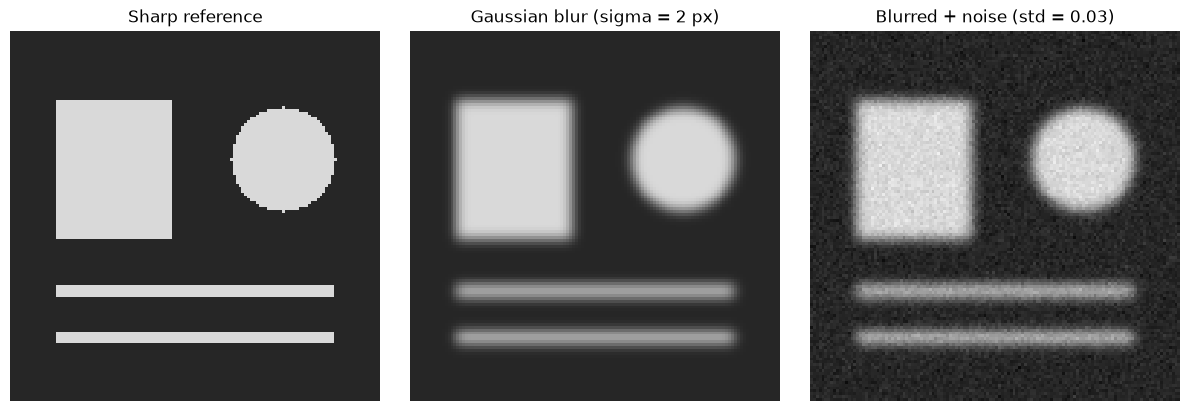

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")

images = [sharp_image, blurred_image, noisy_image]
titles = ["Sharp reference", "Gaussian blur (sigma = 2 px)", "Blurred + noise (std = 0.03)"]

for ax, image, title in zip(axes, images, titles):
    # Fixed limits keep brightness and contrast comparable across all panels.
    ax.imshow(image, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

plt.show()


#### What the images show

- **Sharp reference:** The square, disk, and thin bars have abrupt boundaries and uniform interiors.
- **Gaussian blur:** Nearby pixels are averaged, spreading the boundaries into gradual transitions. Corners soften, and the thin bars lose contrast because their width is comparable to the blur scale.
- **Blurred + noise:** Small random intensity changes add visible grain to the blurred image. The edges remain soft; the grain does not restore the original detail.

All three panels use the same grayscale limits (0 to 1), so the differences come from the blur and noise rather than automatic display scaling. Later deblurring methods must recover sharp structure while avoiding amplification of this noise.


## 3. Ill-conditioning mechanism

**Family B in the assignment's deblurring menu:** a discretized smoothing operator suppresses some image patterns much more strongly than others. This is an inverse-problem mechanism, rather than a mismatch between pixel units.

For periodic convolution, Fourier patterns are eigenvectors of the blur operator. If $\widehat h_\sigma(\omega)$ is the discrete response of the actual sampled Gaussian kernel, the corresponding Hessian curvature is $|\widehat h_\sigma(\omega)|^2$. Fine oscillations can almost cancel under averaging, producing tiny curvatures while the constant pattern has curvature 1. Equivalently, the blur's small singular values are squared in $H=A_\sigma^T A_\sigma$. This creates both slow correction of weak patterns and extreme sensitivity to noisy data.

The structural knob in D2 is $\sigma$ in pixels, with the grid and intensity units held fixed. For example, the current sweep gives spectral condition estimates of about 9.20 at 0.5 pixels, $2.33\times10^7$ at 1 pixel, and $4.02\times10^{17}$ at 1.5 pixels. This is substantial growth under stronger smoothing. The wider sweep has local dips because the finite truncated kernel's weakest response among discrete frequencies can change; we do not assume that every successive width must increase the estimate.

The second intrinsic test is survival under diagonal rescaling. Every periodic kernel column is a circular shift with the same norm, so $D=cI$ and symmetric Jacobi scaling changes every curvature by the same factor. Its exact condition number is unchanged. D2 verifies this constant diagonal and plots both numerical estimates. Together, the growth range and scaling invariance establish the intrinsic mechanism for this model. Noise changes reconstruction difficulty, but does not change this fixed linear problem's Hessian.

The next cell constructs and verifies the shared operator before the D2 sweep. D1's full spectrum is presented in Section 4.


In [5]:
# Reuse the periodic filter settings from Experiment 1.
assert blur_mode == "wrap", "The periodic Jacobi argument requires wrapped boundaries."
assert sharp_image.shape == (image_size, image_size)


def blur_axis_matrix(size, sigma):
    """Column j is the blur of a unit impulse at pixel j along one axis."""
    return gaussian_filter(
        np.eye(size, dtype=float), sigma=(float(sigma), 0.0),
        mode=blur_mode, truncate=blur_truncate,
    )


def hessian_spectrum_from_factor(factor):
    """Spectrum of (factor.T @ factor) tensor (factor.T @ factor)."""
    singular_values = np.linalg.svd(factor, compute_uv=False)
    factor_tolerance = np.finfo(float).eps * factor.shape[0] * singular_values[0]
    if singular_values[-1] <= factor_tolerance:
        raise ValueError("Blur factor is numerically rank deficient; a finite condition estimate is unreliable.")
    eigenvalues = np.sort(np.outer(singular_values**2, singular_values**2).ravel())[::-1]
    condition = eigenvalues[0] / eigenvalues[-1]
    return eigenvalues, condition


B = blur_axis_matrix(image_size, blur_sigma)

# Check both the actual image and a random image that exercises the boundaries.
np.testing.assert_allclose(B @ sharp_image @ B.T, blurred_image, rtol=1e-13, atol=1e-14)
operator_probe = np.random.default_rng(1).normal(size=sharp_image.shape)
probe_blur = gaussian_filter(operator_probe, sigma=blur_sigma, mode=blur_mode, truncate=blur_truncate)
probe_error = np.max(np.abs(B @ operator_probe @ B.T - probe_blur))
np.testing.assert_allclose(B @ operator_probe @ B.T, probe_blur, rtol=1e-13, atol=1e-14)
print(f"Operator matches Experiment 1; random-image maximum difference: {probe_error:.2e}")

# Compute the original-width spectrum once for D2, D1, and D4.
hessian_eigenvalues, hessian_condition = hessian_spectrum_from_factor(B)


Operator matches Experiment 1; random-image maximum difference: 1.94e-16


### D2: Blur width and Jacobi scaling for periodic blur

We hold the grid and periodic filter settings fixed and vary only the Gaussian standard deviation. A width of zero is the no-blur reference. The plotted condition numbers are **spectral estimates**, with the floating-point caveat explained in D1 below.

Symmetric Jacobi scaling uses

$$D=\operatorname{diag}(H), \qquad H_J=D^{-1/2} H D^{-1/2}.$$

For periodic convolution, every column of $A$ is a circular shift of the same blur kernel. Every column therefore has the same squared norm, so every diagonal entry of $H=A^T A$ equals the same positive constant $c$. Consequently,

$$D=cI, \qquad H_J=H/c, \qquad \kappa_2(H_J)=\kappa_2(H).$$

All eigenvalues change by the same factor, so **Jacobi scaling leaves the condition number unchanged in exact arithmetic**. If the blur were exactly singular, scalar scaling would also leave it singular.

We still compute the two estimates separately to show numerical effects. For $G=B^T B$, let $d_j=G_{jj}=\sum_i B_{ij}^2$. Periodicity makes $d_j=d$ constant and $c=d^2$. The scaled factor $C=B\operatorname{diag}(d^{-1/2})$ supplies the estimated spectrum of $H_J$ through the same separable calculation as D1. The code checks that the diagonal is constant to rounding accuracy.


In [6]:
blur_widths = np.array([0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0])
blur_widths = np.unique(np.append(blur_widths, blur_sigma))
raw_conditions = []
jacobi_conditions = []
diagonal_relative_spreads = []

for sigma in blur_widths:
    blur_factor = blur_axis_matrix(image_size, sigma)
    reference_blur = gaussian_filter(operator_probe, sigma=sigma, mode=blur_mode, truncate=blur_truncate)
    np.testing.assert_allclose(blur_factor @ operator_probe @ blur_factor.T, reference_blur, rtol=1e-13, atol=1e-14)

    _, raw_condition = hessian_spectrum_from_factor(blur_factor)
    diagonal_1d = np.sum(blur_factor**2, axis=0)
    # Circular shifts have equal column norms: Jacobi is a scalar in exact arithmetic.
    np.testing.assert_allclose(diagonal_1d, diagonal_1d[0], rtol=1e-13, atol=1e-15)
    diagonal_relative_spreads.append(np.ptp(diagonal_1d) / np.mean(diagonal_1d))
    jacobi_factor = blur_factor / np.sqrt(diagonal_1d)[None, :]
    _, jacobi_condition = hessian_spectrum_from_factor(jacobi_factor)
    raw_conditions.append(raw_condition)
    jacobi_conditions.append(jacobi_condition)

raw_conditions = np.array(raw_conditions)
jacobi_conditions = np.array(jacobi_conditions)
# Differences are numerical deviations from exact invariance, not scaling benefits.
jacobi_numerical_difference_pct = 100 * (jacobi_conditions / raw_conditions - 1)

print("Condition numbers below are spectral estimates, not certified full-Hessian float64 measurements.")
print(f"{'sigma (px)':>10} {'estimate H':>15} {'estimate H_J':>15} {'numerical diff %':>18}")
for sigma, raw, scaled, difference in zip(blur_widths, raw_conditions, jacobi_conditions, jacobi_numerical_difference_pct):
    print(f"{sigma:10.2f} {raw:15.3e} {scaled:15.3e} {difference:18.3e}")

original_index = np.flatnonzero(blur_widths == blur_sigma)[0]
original_jacobi_condition = jacobi_conditions[original_index]
print(f"\nAt the original sigma = {blur_sigma:g} px:")
print(f"Raw spectral estimate: {hessian_condition:.3e}; Jacobi spectral estimate: {original_jacobi_condition:.3e}")
print(f"Maximum relative spread of the one-axis Hessian diagonal: {max(diagonal_relative_spreads):.3e}")
print("Exact-arithmetic Jacobi condition number: unchanged. Plotted deviations are floating-point effects.")


Condition numbers below are spectral estimates, not certified full-Hessian float64 measurements.
sigma (px)      estimate H    estimate H_J   numerical diff %
      0.00       1.000e+00       1.000e+00          0.000e+00
      0.50       9.199e+00       9.199e+00         -1.110e-13
      0.75       4.150e+03       4.150e+03         -6.661e-14
      1.00       2.334e+07       2.334e+07         -1.454e-12
      1.25       1.595e+12       1.595e+12         -3.224e-11
      1.50       4.023e+17       4.023e+17          1.512e-11
      1.75       1.543e+23       1.543e+23          1.420e-09
      2.00       2.272e+22       2.272e+22          6.014e-09
      2.25       7.331e+24       7.331e+24          5.161e-10
      2.50       1.812e+25       1.812e+25          1.987e-08
      3.00       1.771e+21       1.771e+21         -1.069e-09
      3.50       2.691e+23       2.691e+23          6.748e-10
      4.00       1.807e+33       1.807e+33          1.356e-06

At the original sigma = 2 px:
Raw 

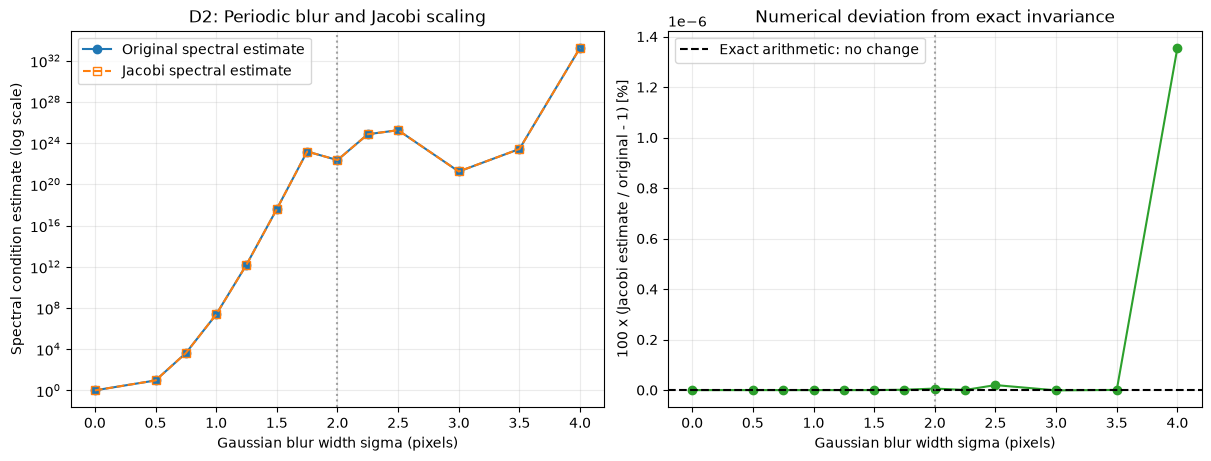

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

axes[0].semilogy(blur_widths, raw_conditions, "o-", label="Original spectral estimate")
axes[0].semilogy(blur_widths, jacobi_conditions, "s--", markerfacecolor="none", label="Jacobi spectral estimate")
axes[0].set_xlabel("Gaussian blur width sigma (pixels)")
axes[0].set_ylabel("Spectral condition estimate (log scale)")
axes[0].set_title("D2: Periodic blur and Jacobi scaling")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].plot(blur_widths, jacobi_numerical_difference_pct, "o-", color="tab:green")
axes[1].axhline(0.0, color="black", linestyle="--", label="Exact arithmetic: no change")
axes[1].set_xlabel("Gaussian blur width sigma (pixels)")
axes[1].set_ylabel("100 x (Jacobi estimate / original - 1) [%]")
axes[1].set_title("Numerical deviation from exact invariance")
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
axes[1].grid(True, alpha=0.25)
axes[1].legend()

for ax in axes:
    ax.axvline(blur_sigma, color="tab:gray", linestyle=":", alpha=0.7)
plt.show()


#### Reading D2: unchanged conditioning in exact arithmetic

With no blur, the Hessian is the identity and the condition number is 1. Wider blur usually suppresses more fine detail and makes recovery harder. The spectral estimates need not rise monotonically: this finite, sampled Gaussian kernel is truncated at four standard deviations, and its weakest response among the discrete periodic frequencies can change sharply as the width changes. Extremely large estimates also require the floating-point caution described in D1.

The original and Jacobi spectral estimates overlap. At the current width of 2 pixels, both are about $2.27\times10^{22}$. For this periodic blur, **the exact condition numbers are identical at every width**, because Jacobi merely multiplies the whole Hessian by a scalar. It cannot reduce the ratio between the strongest and weakest curvatures.

The second plot magnifies the small deviations between separately computed estimates. These come from rounding while normalizing the factors and recomputing their singular values; tiny singular values can amplify relative numerical differences. Positive and negative deviations should not be interpreted as genuine worsening or improvement from Jacobi scaling. The exact-arithmetic reference is zero.

In plain language, all pixels already have the same scale in a periodic blur. Rescaling them equally cannot recover detail removed by smoothing. A useful later remedy must address weak image patterns and noise, such as regularization.

Sources: [SciPy Gaussian filter boundary modes](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html), [Jacobi preconditioning](https://netlib.org/linalg/old_html_templates/section2.7.2.html), and [LAPACK singular-value error bounds](https://www.netlib.org/lapack/lug/node97.html).


## 4. Effect of ill-conditioning

D1 reports the full Hessian spectrum and its spectral condition estimate on a logarithmic axis. D3 then tests ordinary gradient descent from $x_0=0$ at widths 0.5 and 2 pixels. Each run uses a matching observation and the same noise sample.

For a quadratic objective, the error component along a Hessian eigenvector with eigenvalue $\nu$ is multiplied by $1-\alpha\nu$ per update. With $\alpha=1/L$, large-curvature components decrease rapidly, whereas tiny-curvature components change extremely slowly. This explains the fast initial decrease and slow tail without requiring a reliably computed unregularized optimum.

The fixed stopping tolerance is $\|\nabla f(x_k)\|_2/\|\nabla f(0)\|_2\le10^{-5}$, checked after each completed update, with a 5,000-update limit. The semilog gradient plot supplies the assignment's convergence diagnostic. The objective plot is explicitly a normalized objective value, not an estimated objective gap. This problem has 16,384 variables, so a two-variable contour/iterate-path plot is not applicable.


### D1: Hessian eigenvalues and spectral condition estimate

For the unregularized least-squares blur problem, let $x$ be the unknown sharp image, $y$ the blurred, noisy observation, and $A$ the blur operator:

$$f(x)=\tfrac12\|Ax-y\|_2^2, \qquad H=\nabla^2 f=A^T A.$$

The Hessian depends on the blur, not on the particular image or noise realization. We use the **same 128 x 128 grid, Gaussian width, periodic boundaries (`mode="wrap"`), and kernel truncation at four standard deviations** as Experiment 1.

Gaussian blur is separable: if $B$ blurs one image axis, then the blurred image is $B X B^T$. Thus $A=B\otimes B$ and $H=(B^T B)\otimes(B^T B)$. If $s_i$ are the singular values of $B$, the Hessian eigenvalues are $s_i^2 s_j^2$.

We estimate all 16,384 eigenvalues from the 128 x 128 factor, without forming the large Hessian or clipping its tiny eigenvalues. The reported ratio $\lambda_{\max}/\lambda_{\min}$ is a **spectral estimate of $\kappa_2(H)$**, rather than a reliably resolved condition number of an explicitly assembled float64 Hessian when the ratio is extremely large.


Hessian size: 16,384 x 16,384
Periodic blur width: sigma = 2 pixels
Estimated largest eigenvalue: 1.000e+00
Estimated smallest eigenvalue: 4.401e-23
Spectral estimate of cond(H): 2.272e+22
float64 epsilon: 2.220e-16; inverse epsilon: 4.504e+15
Estimated eigenvalues below eps * largest eigenvalue: 2,693 / 16,384
The smallest curvatures are unresolved at full-Hessian float64 precision; the large ratio is a structured spectral estimate.


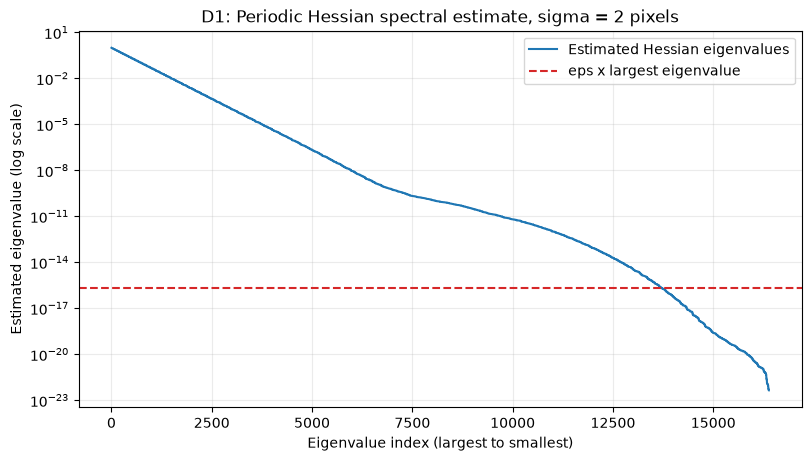

In [8]:
# Use the shared spectrum already constructed in Section 3.
float64_epsilon = np.finfo(float).eps
hessian_roundoff_scale = float64_epsilon * hessian_eigenvalues[0]
below_roundoff = np.count_nonzero(hessian_eigenvalues < hessian_roundoff_scale)

print(f"Hessian size: {image_size**2:,} x {image_size**2:,}")
print(f"Periodic blur width: sigma = {blur_sigma:g} pixels")
print(f"Estimated largest eigenvalue: {hessian_eigenvalues[0]:.3e}")
print(f"Estimated smallest eigenvalue: {hessian_eigenvalues[-1]:.3e}")
print(f"Spectral estimate of cond(H): {hessian_condition:.3e}")
print(f"float64 epsilon: {float64_epsilon:.3e}; inverse epsilon: {1 / float64_epsilon:.3e}")
print(f"Estimated eigenvalues below eps * largest eigenvalue: {below_roundoff:,} / {hessian_eigenvalues.size:,}")
print("The smallest curvatures are unresolved at full-Hessian float64 precision; the large ratio is a structured spectral estimate.")

fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.semilogy(np.arange(1, hessian_eigenvalues.size + 1), hessian_eigenvalues, label="Estimated Hessian eigenvalues")
ax.axhline(hessian_roundoff_scale, color="tab:red", linestyle="--", label="eps x largest eigenvalue")
ax.set_xlabel("Eigenvalue index (largest to smallest)")
ax.set_ylabel("Estimated eigenvalue (log scale)")
ax.set_title(f"D1: Periodic Hessian spectral estimate, sigma = {blur_sigma:g} pixels")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()


#### Reading D1: what the estimate means

Large eigenvalues describe image patterns that still affect the blurred observation strongly. Tiny eigenvalues describe patterns, often fine detail, that blur almost removes. Recovering those weak patterns is sensitive to noise.

At the current periodic blur width of 2 pixels, the estimated eigenvalues range from about 1 to $4.40\times10^{-23}$. Their ratio, about $2.27\times10^{22}$, is a **spectral condition estimate** that signals severe ill-conditioning. It is not a condition number whose digits are certified by a direct float64 Hessian calculation.

Float64 machine epsilon is about $2.22\times10^{-16}$. When a Hessian eigenvalue is far below $\epsilon\lambda_{\max}$, rounding in an explicitly formed Hessian or an ordinary dense eigensolver can overwhelm it. Here 2,693 estimated eigenvalues lie below that reference line. The reciprocal $1/\epsilon\approx4.50\times10^{15}$ is a useful caution scale for direct Hessian calculations, not a universal upper limit on structured spectral estimates.

The separable calculation avoids forming $H$: its one-axis singular values are still above their own rounding scale, so it can estimate attenuation below the full-Hessian reference line. This does not recover trustworthy precision in the assembled Hessian, certify all printed digits, or prove an exactly zero eigenvalue. The dashed line is a precision reference, not a cutoff applied to the spectrum.


### D3: Baseline gradient descent for unregularized deblurring

We minimize the same objective as D1 and D2, using the same periodic Gaussian filter:

$$f_\sigma(x)=\tfrac12\|A_\sigma x-y_\sigma\|_2^2, \qquad \nabla f_\sigma(x)=A_\sigma^T(A_\sigma x-y_\sigma).$$

For each width, $y_\sigma=A_\sigma x_{\mathrm{sharp}}+\mathrm{noise}$. The sharp image and the exact noise sample from Experiment 1 are shared between runs; only the blur width changes. This avoids pairing an observation from one width with an operator from another.

The normalized, symmetric Gaussian kernel with periodic boundaries is self-adjoint, so $A_\sigma^T=A_\sigma$. Its Hessian has largest eigenvalue $L=\|A_\sigma\|_2^2=1$. We use the same fixed gradient descent step $\alpha=1/L=1$ for both widths:

$$x_{k+1}=x_k-\alpha\nabla f_\sigma(x_k), \qquad x_0=0.$$

**One fixed stopping tolerance:** stop when $\|\nabla f_\sigma(x_k)\|_2/\|\nabla f_\sigma(x_0)\|_2\le10^{-5}$. Each run is limited to **5,000 updates**. Iteration zero is the initial image, and reaching the limit without satisfying the tolerance is reported explicitly. The iterates are unconstrained and the objective is unregularized.


In [9]:
gd_blur_widths = np.unique(np.array([0.5, blur_sigma], dtype=float))
assert gd_blur_widths.size >= 2, "Choose two distinct blur widths for D3."
assert blur_mode == "wrap", "The self-adjoint blur and step-size argument require the periodic model."
gd_step_size = 1.0
gd_stopping_tolerance = 1e-5
gd_max_iterations = 5000


def apply_gd_blur(image, sigma):
    return gaussian_filter(image, sigma=sigma, mode=blur_mode, truncate=blur_truncate)


def baseline_gradient_descent(observation, sigma, step_size, tolerance, max_iterations):
    """Plain GD; record the objective and relative gradient at every iterate."""
    estimate = np.zeros_like(observation, dtype=float)
    objectives = []
    relative_gradients = []
    initial_gradient_norm = None

    for iteration in range(max_iterations + 1):
        residual = apply_gd_blur(estimate, sigma) - observation
        gradient = apply_gd_blur(residual, sigma)  # A.T = A for this symmetric periodic blur.
        gradient_norm = np.linalg.norm(gradient.ravel())
        if initial_gradient_norm is None:
            initial_gradient_norm = gradient_norm
        relative_gradient = gradient_norm / initial_gradient_norm if initial_gradient_norm > 0 else 0.0

        objectives.append(0.5 * np.sum(residual**2))
        relative_gradients.append(relative_gradient)
        converged = relative_gradient <= tolerance
        if converged or iteration == max_iterations:
            break
        estimate = estimate - step_size * gradient

    return {
        "sigma": sigma,
        "solution": estimate,
        "iterations": iteration,
        "converged": converged,
        "objective": np.array(objectives),
        "relative_gradient": np.array(relative_gradients),
    }


In [10]:
gd_results = []

# Confirm the adjoint property numerically, including the wrapped boundaries.
adjoint_rng = np.random.default_rng(2)
adjoint_probe_a = adjoint_rng.normal(size=sharp_image.shape)
adjoint_probe_b = adjoint_rng.normal(size=sharp_image.shape)

for sigma in gd_blur_widths:
    np.testing.assert_allclose(
        np.vdot(apply_gd_blur(adjoint_probe_a, sigma), adjoint_probe_b),
        np.vdot(adjoint_probe_a, apply_gd_blur(adjoint_probe_b, sigma)),
        rtol=1e-12, atol=1e-12,
    )
    observation = apply_gd_blur(sharp_image, sigma) + noise
    if sigma == blur_sigma:
        np.testing.assert_allclose(observation, noisy_image, rtol=1e-13, atol=1e-14)
    result = baseline_gradient_descent(
        observation, sigma, gd_step_size, gd_stopping_tolerance, gd_max_iterations,
    )
    gd_results.append(result)

print(f"Fixed step size: {gd_step_size:g}; fixed relative-gradient tolerance: {gd_stopping_tolerance:.1e}")
print(f"Maximum updates per run: {gd_max_iterations:,}; initialization: zero image")
print(f"{'sigma (px)':>10} {'updates':>10} {'final rel. grad.':>18} {'final objective':>18}  status")
for result in gd_results:
    status = "TOLERANCE REACHED" if result["converged"] else "ITERATION LIMIT REACHED (tolerance not met)"
    print(f"{result['sigma']:10.2f} {result['iterations']:10,d} {result['relative_gradient'][-1]:18.3e} {result['objective'][-1]:18.3e}  {status}")


Fixed step size: 1; fixed relative-gradient tolerance: 1.0e-05
Maximum updates per run: 5,000; initialization: zero image
sigma (px)    updates   final rel. grad.    final objective  status
      0.50         51          9.336e-06          1.059e-06  TOLERANCE REACHED
      2.00      5,000          1.049e-04          5.867e+00  ITERATION LIMIT REACHED (tolerance not met)


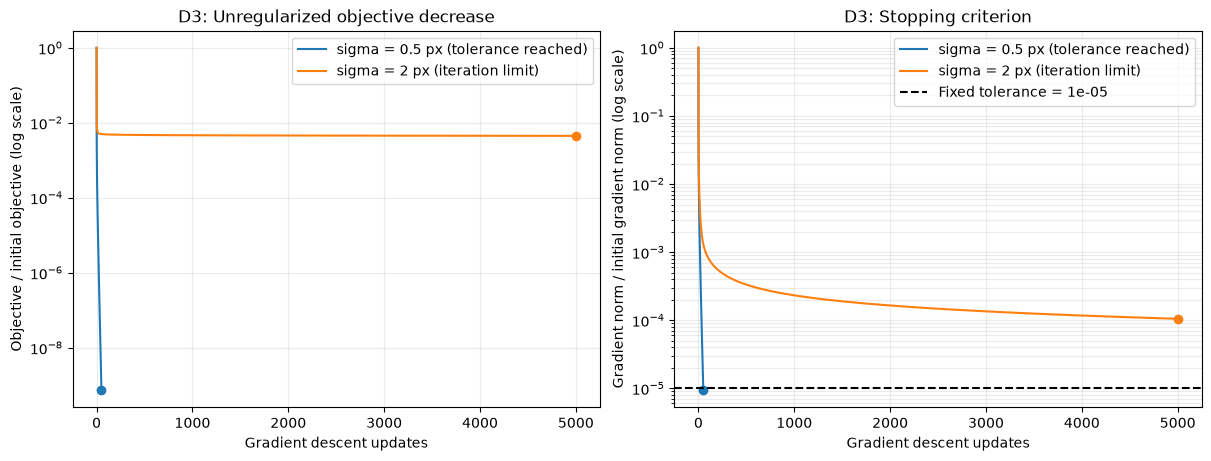

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

for result in gd_results:
    iterations = np.arange(result["iterations"] + 1)
    status = "tolerance reached" if result["converged"] else "iteration limit"
    label = f"sigma = {result['sigma']:g} px ({status})"
    objective_line, = axes[0].semilogy(iterations, result["objective"] / result["objective"][0], label=label)
    gradient_line, = axes[1].semilogy(iterations, result["relative_gradient"], label=label)
    # Mark each run's final iterate so an early stop is visible.
    axes[0].plot(iterations[-1], result["objective"][-1] / result["objective"][0], "o", color=objective_line.get_color())
    axes[1].plot(iterations[-1], result["relative_gradient"][-1], "o", color=gradient_line.get_color())

axes[0].set_ylabel("Objective / initial objective (log scale)")
axes[0].set_title("D3: Unregularized objective decrease")
axes[1].axhline(gd_stopping_tolerance, color="black", linestyle="--", label=f"Fixed tolerance = {gd_stopping_tolerance:.0e}")
axes[1].set_ylabel("Gradient norm / initial gradient norm (log scale)")
axes[1].set_title("D3: Stopping criterion")

for ax in axes:
    ax.set_xlabel("Gradient descent updates")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()


#### Reading D3

Both runs reduce the objective rapidly at first. The narrow blur lets ordinary gradient descent reach the fixed stopping tolerance, while the wider blur develops a long, slow tail and reaches the iteration limit before meeting it. The table reports the exact update count and final relative gradient for each run.

This fits the conditioning picture in D1 and D2. Gradient descent can correct patterns that remain strongly visible after blur quickly. Patterns that blur almost removes have very small curvature, so their corrections proceed slowly with a fixed step size. A quick initial drop therefore does not mean the whole deblurring problem has been solved.

The left panel plots the objective divided by its initial value, **not an objective gap to a computed optimum**. The right panel plots the actual stopping criterion; its dashed line is the same $10^{-5}$ tolerance for both runs. Reaching 5,000 updates is an iteration-limit outcome, not convergence.

A small relative gradient measures approximate stationarity. It does not certify accurate recovery of the sharp image, and the gradient values alone cannot rank conditioning across widths because blur also suppresses gradients in weak directions. These observations contain noise: continuing to minimize the unregularized objective can fit that noise rather than recover useful image detail. This experiment establishes the baseline for a later regularization comparison.


## 5. Proposed solution and demonstration

The remedy is standard Tikhonov regularization with an identity penalty. It adds $\lambda$ to every Hessian eigenvalue, giving nearly flat directions a positive curvature floor. This addresses the spectral mechanism directly; periodic Jacobi scaling cannot provide that floor.

D4 compares the original-width baseline with regularized gradient descent on exactly the same observation. Both use the same zero start, relative-gradient tolerance $10^{-5}$, and 5,000-update cap. Each uses $1/L$ for its own objective. The comparison reports the condition number, stopping outcome, reconstruction RMSE, data fit, and side-by-side images. It also measures noiseless regularization bias and propagated noise separately.

We fix $\lambda=0.01$ as an illustrative 1% curvature floor. It limits the regularized inverse's largest spectral noise gain to 5 while introducing attenuation of true image content. This parameter is not tuned using the sharp-image RMSE and is not claimed to be optimal. Regularization changes the objective and the desired reconstruction; it is not merely a faster method for the original inverse. Comparisons of the two objective values are therefore kept separate from image quality and stopping diagnostics.


### D4: Tikhonov regularization as the proposed remedy

We keep **the original periodic blur, width of 2 pixels, and exact blurred noisy image `noisy_image`**. Standard Tikhonov regularization penalizes the image's squared size:

$$F_\lambda(x)=\tfrac12\|Ax-y\|_2^2+\tfrac\lambda2\|x\|_2^2, \qquad \nabla F_\lambda(x)=A^T(Ax-y)+\lambda x.$$

The Hessian becomes $H_\lambda=A^T A+\lambda I$. Every eigenvalue gains $\lambda$, so

$$\kappa_2(H_\lambda)=\frac{\lambda_{\max}(H)+\lambda}{\lambda_{\min}(H)+\lambda}.$$

We choose **$\lambda=0.01$**, about 1% of the largest unregularized Hessian eigenvalue. This is an illustrative stabilization parameter, not a value optimized against the known sharp image. In this notebook, $\lambda$ is the coefficient of the penalty; references that write a squared parameter use $\lambda_{\mathrm{ref}}^2=0.01$.

Both methods start from zero, use the same observation, and stop when **$\|\nabla F_{\mathrm{method}}(x_k)\|_2/\|\nabla F_{\mathrm{method}}(0)\|_2\le10^{-5}$**, with a **5,000-update limit**. At zero, the penalty gradient is zero, so both initial gradient norms equal $\|A^T y\|_2$. The step-size rule is $1/L$ for each objective: $1$ without regularization and $1/(1+\lambda)$ with regularization. This compares the same gradient descent method with a stable step for each Hessian.

We reuse the original-width D3 baseline and compute the regularized run. The displayed reconstructions are the actual final GD iterates; an iteration-limit outcome is not labeled as a converged minimizer.


In [12]:
d4_lambda = 0.01
assert d4_lambda > 0, "Tikhonov regularization requires a positive penalty coefficient."
d4_tolerance = gd_stopping_tolerance  # Same relative-gradient rule as D3: 1e-5.
d4_max_iterations = gd_max_iterations  # Same limit: 5000 updates.
d4_step_size = 1.0 / (hessian_eigenvalues[0] + d4_lambda)
d4_regularized_eigenvalues = hessian_eigenvalues + d4_lambda
d4_regularized_condition = d4_regularized_eigenvalues[0] / d4_regularized_eigenvalues[-1]
d4_noise_gain_bound = 1.0 / (2 * np.sqrt(d4_lambda))

print(f"Original blur width: {blur_sigma:g} px; Tikhonov lambda: {d4_lambda:g}")
print(f"Unregularized Hessian condition: {hessian_condition:.3e} (spectral estimate; see D1 precision caveat)")
print(f"Regularized Hessian condition: {d4_regularized_condition:.3f}")
print(f"Regularized eigenvalue range: [{d4_regularized_eigenvalues[-1]:.3e}, {d4_regularized_eigenvalues[0]:.3e}]")
print(f"GD step sizes: unregularized = {gd_step_size:g}, regularized = {d4_step_size:.6f}")
print(f"Common relative-gradient tolerance: {d4_tolerance:.1e}; maximum updates: {d4_max_iterations:,}")
print(f"Regularized spectral noise-gain bound: {d4_noise_gain_bound:.3f}")


Original blur width: 2 px; Tikhonov lambda: 0.01
Unregularized Hessian condition: 2.272e+22 (spectral estimate; see D1 precision caveat)
Regularized Hessian condition: 101.000
Regularized eigenvalue range: [1.000e-02, 1.010e+00]
GD step sizes: unregularized = 1, regularized = 0.990099
Common relative-gradient tolerance: 1.0e-05; maximum updates: 5,000
Regularized spectral noise-gain bound: 5.000


In [13]:
def tikhonov_gradient_descent(observation, sigma, weight, step_size, tolerance, max_iterations):
    """Unconstrained GD for half squared residual plus weight/2 times squared image norm."""
    estimate = np.zeros_like(observation, dtype=float)
    objectives = []
    data_fits = []
    relative_gradients = []
    initial_gradient_norm = None

    for iteration in range(max_iterations + 1):
        residual = apply_gd_blur(estimate, sigma) - observation
        gradient = apply_gd_blur(residual, sigma) + weight * estimate
        gradient_norm = np.linalg.norm(gradient.ravel())
        if initial_gradient_norm is None:
            initial_gradient_norm = gradient_norm
        relative_gradient = gradient_norm / initial_gradient_norm if initial_gradient_norm > 0 else 0.0
        data_fit = 0.5 * np.sum(residual**2)

        data_fits.append(data_fit)
        objectives.append(data_fit + 0.5 * weight * np.sum(estimate**2))
        relative_gradients.append(relative_gradient)
        converged = relative_gradient <= tolerance
        if converged or iteration == max_iterations:
            break
        estimate = estimate - step_size * gradient

    return {
        "solution": estimate,
        "iterations": iteration,
        "converged": converged,
        "objective": np.array(objectives),
        "data_fit": np.array(data_fits),
        "relative_gradient": np.array(relative_gradients),
    }


In [14]:
# The original-width D3 observation is exactly this same noisy_image.
np.testing.assert_allclose(apply_gd_blur(sharp_image, blur_sigma) + noise, noisy_image, rtol=1e-13, atol=1e-14)
d4_unregularized = next(result for result in gd_results if result["sigma"] == blur_sigma)
d4_regularized = tikhonov_gradient_descent(
    noisy_image, blur_sigma, d4_lambda, d4_step_size, d4_tolerance, d4_max_iterations,
)
d4_cases = [("Unregularized (D3)", 0.0, d4_unregularized), ("Tikhonov GD", d4_lambda, d4_regularized)]
d4_metrics = []

print(f"{'method':>20} {'updates':>9} {'relative grad.':>16} {'image RMSE':>13} {'data fit':>12} {'own objective':>15}  outcome")
for name, weight, result in d4_cases:
    estimate = result["solution"]
    residual = apply_gd_blur(estimate, blur_sigma) - noisy_image
    rmse = np.sqrt(np.mean((estimate - sharp_image)**2))
    data_fit = 0.5 * np.sum(residual**2)
    own_objective = data_fit + 0.5 * weight * np.sum(estimate**2)
    outcome = "TOLERANCE REACHED" if result["converged"] else "ITERATION LIMIT REACHED (tolerance not met)"
    d4_metrics.append({"name": name, "rmse": rmse, "data_fit": data_fit, "own_objective": own_objective})
    print(f"{name:>20} {result['iterations']:9,d} {result['relative_gradient'][-1]:16.3e} {rmse:13.5f} {data_fit:12.3e} {own_objective:15.3e}  {outcome}")
    print(f"  Unclipped image range: [{estimate.min():.4f}, {estimate.max():.4f}]")

# A structured reference checks the regularized minimizer and separates bias from noise.
# The FFT uses an impulse blurred by the actual operator, not an ideal Gaussian formula.
d4_impulse = np.zeros_like(sharp_image)
d4_impulse[0, 0] = 1.0
d4_transfer = np.fft.fft2(apply_gd_blur(d4_impulse, blur_sigma))
d4_fft_probe = np.fft.ifft2(d4_transfer * np.fft.fft2(operator_probe)).real
np.testing.assert_allclose(d4_fft_probe, apply_gd_blur(operator_probe, blur_sigma), rtol=1e-12, atol=1e-13)
d4_filter = np.conj(d4_transfer) / (np.abs(d4_transfer)**2 + d4_lambda)
d4_reference = np.fft.ifft2(d4_filter * np.fft.fft2(noisy_image)).real
d4_noiseless_reference = np.fft.ifft2(d4_filter * np.fft.fft2(blurred_image)).real
d4_bias_rmse = np.sqrt(np.mean((d4_noiseless_reference - sharp_image)**2))
d4_propagated_noise_rmse = np.sqrt(np.mean((d4_reference - d4_noiseless_reference)**2))
d4_gd_reference_error = np.linalg.norm(d4_regularized["solution"] - d4_reference) / np.linalg.norm(d4_reference)

print(f"\nRegularized GD relative distance to the FFT minimizer: {d4_gd_reference_error:.3e}")
print(f"Noiseless Tikhonov bias RMSE: {d4_bias_rmse:.5f}")
print(f"Propagated noise RMSE for the regularized minimizer: {d4_propagated_noise_rmse:.5f}")
print(f"Actual maximum spectral noise gain: {np.max(np.abs(d4_filter)):.5f}; bound: {d4_noise_gain_bound:g}")
print("RMSE uses the known sharp image for evaluation only; it is not a stopping or parameter-selection criterion.")


              method   updates   relative grad.    image RMSE     data fit   own objective  outcome
  Unregularized (D3)     5,000        1.049e-04       0.34352    5.867e+00       5.867e+00  ITERATION LIMIT REACHED (tolerance not met)
  Unclipped image range: [-1.1984, 2.2944]
         Tikhonov GD       369        9.999e-06       0.08101    6.680e+00       2.075e+01  TOLERANCE REACHED
  Unclipped image range: [-0.0228, 1.0332]

Regularized GD relative distance to the FFT minimizer: 8.359e-04
Noiseless Tikhonov bias RMSE: 0.06881
Propagated noise RMSE for the regularized minimizer: 0.04290
Actual maximum spectral noise gain: 4.99996; bound: 5
RMSE uses the known sharp image for evaluation only; it is not a stopping or parameter-selection criterion.


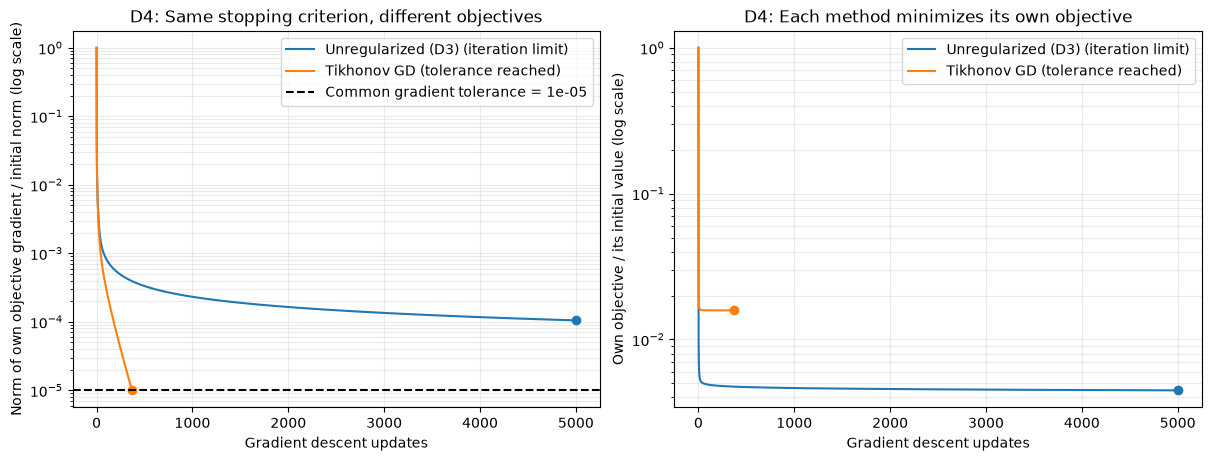

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

for name, weight, result in d4_cases:
    iterations = np.arange(result["iterations"] + 1)
    outcome = "tolerance reached" if result["converged"] else "iteration limit"
    label = f"{name} ({outcome})"
    gradient_line, = axes[0].semilogy(iterations, result["relative_gradient"], label=label)
    objective_line, = axes[1].semilogy(iterations, result["objective"] / result["objective"][0], label=label)
    axes[0].plot(iterations[-1], result["relative_gradient"][-1], "o", color=gradient_line.get_color())
    axes[1].plot(iterations[-1], result["objective"][-1] / result["objective"][0], "o", color=objective_line.get_color())

axes[0].axhline(d4_tolerance, color="black", linestyle="--", label=f"Common gradient tolerance = {d4_tolerance:.0e}")
axes[0].set_ylabel("Norm of own objective gradient / initial norm (log scale)")
axes[0].set_title("D4: Same stopping criterion, different objectives")
axes[1].set_ylabel("Own objective / its initial value (log scale)")
axes[1].set_title("D4: Each method minimizes its own objective")
for ax in axes:
    ax.set_xlabel("Gradient descent updates")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()


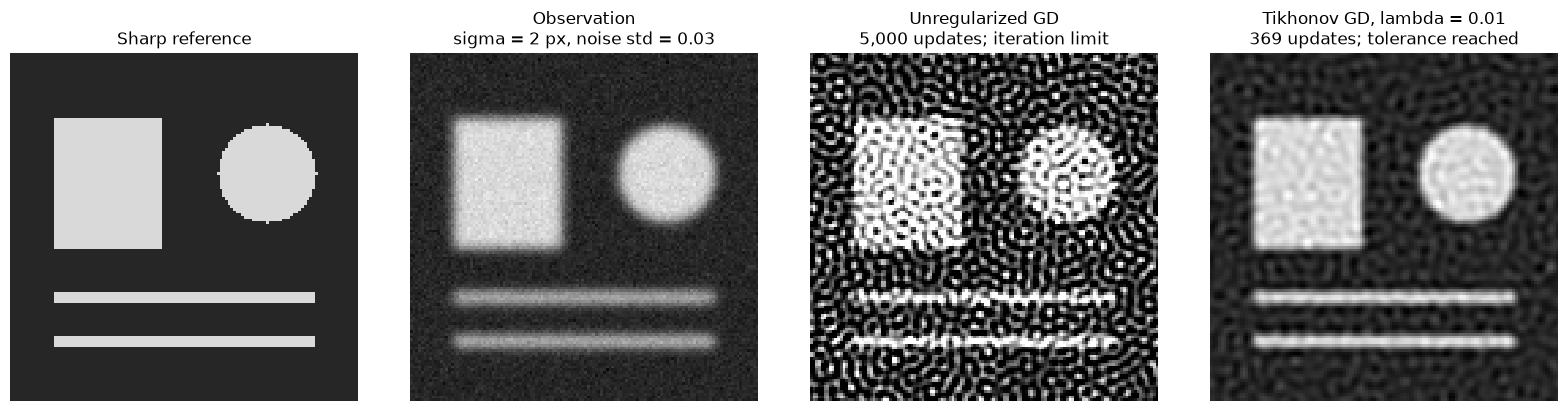

All panels use grayscale limits 0 to 1. Values outside that range saturate in the display only; arrays and RMSE are not clipped.


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
d4_display_images = [sharp_image, noisy_image, d4_unregularized["solution"], d4_regularized["solution"]]
d4_unregularized_outcome = "tolerance reached" if d4_unregularized["converged"] else "iteration limit"
d4_regularized_outcome = "tolerance reached" if d4_regularized["converged"] else "iteration limit"
d4_titles = [
    "Sharp reference",
    f"Observation\nsigma = {blur_sigma:g} px, noise std = {noise_std:g}",
    f"Unregularized GD\n{d4_unregularized['iterations']:,} updates; {d4_unregularized_outcome}",
    f"Tikhonov GD, lambda = {d4_lambda:g}\n{d4_regularized['iterations']:,} updates; {d4_regularized_outcome}",
]
for ax, image, title in zip(axes, d4_display_images, d4_titles):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.show()
print("All panels use grayscale limits 0 to 1. Values outside that range saturate in the display only; arrays and RMSE are not clipped.")


#### Reading D4: faster optimization and the noise-bias tradeoff

The regularized Hessian has a condition number of about **101**, compared with the unregularized **spectral estimate of $2.27\times10^{22}$**. The unregularized precision caveat from D1 still applies. Regularization raises the tiny curvatures to at least 0.01, well above the floating-point reference scale, instead of merely rescaling all curvatures as periodic Jacobi scaling did.

The regularized run reaches the common relative-gradient tolerance, whereas the unregularized D3 run reaches its 5,000-update limit. The convergence panel measures each method's own gradient: $\nabla F_0$ for the baseline and $\nabla F_\lambda$ for Tikhonov. The normalized objective curves also describe different objectives; a lower value on those curves does not by itself mean a better reconstructed image. The table separately reports the shared data-fit term and image RMSE.

The unregularized final iterate shows strong grain and large intensity excursions. Tikhonov keeps the shapes more stable and substantially reduces reconstruction error in this example. The baseline image is a capped GD iterate, not the fully converged unregularized inverse; early stopping already limits some noise amplification.

For a blur singular value $s$, the unregularized inverse has gain $1/s$. Tikhonov replaces this with $s/(s^2+\lambda)$, whose maximum is at most $1/(2\sqrt\lambda)=5$ here. Weakly observed patterns therefore cannot amplify noise without bound. This bound describes the regularized minimizer; the side-by-side image shows its GD approximation.

The price is **bias**. Even with noiseless data, a true image component is multiplied by $s^2/(s^2+\lambda)$, so fine detail is attenuated, edges remain softened, and brightness is slightly reduced. The noiseless reference calculation reports this bias separately from propagated noise. Those two RMS errors are not added to obtain total RMSE, because a particular noise realization can have a cross term with the bias. Increasing $\lambda$ generally reduces noise gain further while increasing attenuation; the chosen 0.01 demonstrates this tradeoff and is not claimed to be optimal.

All images share the same grayscale limits. Out-of-range intensities saturate visually, and the printed ranges expose those excursions; all calculations use the original unclipped arrays. Sharp-image RMSE is an evaluation metric for this synthetic experiment, not information used by the optimizer.

Background: [Hansen's regularization-method notes](https://www2.compute.dtu.dk/~pcha/DIP/chap4.pdf) describe Tikhonov filtering and the stability-bias tradeoff, using a squared-parameter convention rather than this notebook's penalty coefficient.


## 6. Assumptions and simplifications

- **Known blur:** the point-spread function is a spatially uniform, symmetric, separable, normalized Gaussian. The blur width is known. We do not estimate an unknown kernel or model motion blur, spatially varying defocus, or blur-model error.
- **Periodic boundaries:** the image wraps at its edges. This supports the circulant spectrum, self-adjoint operator, FFT check, and exact Jacobi invariance. Real photographs generally do not have this boundary behavior.
- **Finite discrete model:** the grid is fixed at $128\times128$, and SciPy truncates the sampled Gaussian kernel at four standard deviations. Data generation, gradients, and spectral/FFT checks use the same discrete kernel. No continuous-Gaussian spectrum is substituted for it.
- **Synthetic signal and noise:** a grayscale image of geometric shapes represents boundaries and fine features. Noise is modeled as independent, zero-mean, additive Gaussian samples with standard deviation 0.03. There is no color, quantization, saturation, Poisson noise, correlated noise, or sensor calibration model.
- **Shared realizations:** `default_rng(0)` fixes the observation noise. Width comparisons reuse that exact noise sample and sharp image. Seeds 1 and 2 create operator/adjoint verification probes; they do not regenerate the observations. Once the data are fixed, the optimizers are deterministic.
- **Unconstrained intensities:** physical intensity bounds are omitted to isolate conditioning. Display limits 0 to 1 only control visualization. Negative values and overshoots remain in the optimization and RMSE calculations.
- **Finite precision:** calculations use float64. The unregularized condition number is a structured spectral estimate, with the D1 precision caveat; $1/\epsilon$ is a caution scale for direct Hessian computations, not a universal limit on all condition estimates. Small Jacobi differences are numerical effects, not genuine changes in exact conditioning.
- **Stopping and evaluation:** a relative gradient tolerance measures stationarity of each method's own objective, not reconstruction accuracy. An iteration-limit outcome is not convergence. The sharp image is available only for synthetic evaluation; a real reconstruction would not have ground-truth RMSE.
- **Limited remedy study:** the identity penalty favors smaller intensities, including slight brightness shrinkage, and attenuates detail. One regularization parameter and one noise realization are tested. Derivative penalties, edge-preserving priors, parameter-selection methods, multiple trials, and real-image validation are outside this experiment.

### What the results support

At the original 2-pixel width, ordinary GD reaches the 5,000-update limit with relative gradient about $1.05\times10^{-4}$. Tikhonov reaches $10^{-5}$ in 369 updates, changes the Hessian condition from a spectral estimate of about $2.27\times10^{22}$ to 101, and reduces image RMSE from about 0.3435 to 0.0810. These results support stabilization of this synthetic inverse problem, with a measurable noise-bias tradeoff; they do not establish general performance on real inspection images.

### Reproducibility

Restart the kernel and run all cells in their displayed order. The setup requires only the packages already listed in `requirements.txt`; all image data are generated in the notebook. The final analytic check below independently checks the spectrum, diagonal rescaling, and stopping counts on a tiny instance of the same model. Small last-digit differences can occur across library and BLAS versions without changing the main conclusions.


### Analytic check on a 2 x 2 periodic blur

For this small sanity check, $B=\begin{bmatrix}a&b\\b&a\end{bmatrix}$, with $a+b=1$ and $q=a-b$. Its eigenvalues are 1 and $q$. Thus $A=B\otimes B$ has singular values $s=(1,q,q,q^2)$ and $H$ has eigenvalues $(1,q^2,q^2,q^4)$, giving $\kappa(H)=1/q^4$. The diagonal of $H$ is constant, so Jacobi scaling leaves this ratio unchanged.

For an impulse observation, all four orthonormal Fourier coefficients have magnitude $1/2$. With penalty weight $w$ and step $\alpha=1/(1+w)$, the relative gradient has the explicit formula

$$r_k^2=\frac{\sum_i s_i^2[1-\alpha(s_i^2+w)]^{2k}}{\sum_i s_i^2}.$$

The first $k$ with $r_k\le10^{-5}$ predicts the stopping count without running an optimizer. The cell compares these analytic predictions with the actual GD routines for both $w=0$ and $w=0.01$.


In [17]:
small_sigma = 0.5
small_B = blur_axis_matrix(2, small_sigma)
a, b = small_B[0]
q = a - b
np.testing.assert_allclose(a + b, 1.0, rtol=1e-13, atol=1e-14)
small_A = np.kron(small_B, small_B)
small_H = small_A.T @ small_A
analytic_eigenvalues = np.sort(np.array([1.0, q**2, q**2, q**4]))
np.testing.assert_allclose(np.linalg.eigvalsh(small_H), analytic_eigenvalues, rtol=1e-12, atol=1e-14)
small_spectrum, small_condition = hessian_spectrum_from_factor(small_B)
np.testing.assert_allclose(small_spectrum[::-1], analytic_eigenvalues, rtol=1e-12, atol=1e-14)
np.testing.assert_allclose(small_condition, 1 / q**4, rtol=1e-12)
small_diag = np.diag(small_H)
small_J = small_H / np.sqrt(np.outer(small_diag, small_diag))
np.testing.assert_allclose(np.linalg.cond(small_J), small_condition, rtol=1e-12)
print(f"2 x 2 blur: a = {a:.9f}, b = {b:.9f}, q = {q:.9f}")
print(f"Analytic condition: {1 / q**4:.9f}; computed: {small_condition:.9f}; Jacobi: {np.linalg.cond(small_J):.9f}")

small_observation = np.zeros((2, 2))
small_observation[0, 0] = 1.0
small_singular_values = np.array([1.0, q, q, q**2])
candidate_iterations = np.arange(1001)
for weight in [0.0, d4_lambda]:
    step = 1.0 / (1.0 + weight)
    decay = 1.0 - step * (small_singular_values**2 + weight)
    predicted_relative_gradient = np.sqrt(
        np.sum(small_singular_values[:, None]**2 * decay[:, None]**(2 * candidate_iterations[None, :]), axis=0)
        / np.sum(small_singular_values**2)
    )
    expected_count = int(np.flatnonzero(predicted_relative_gradient <= gd_stopping_tolerance)[0])
    if weight == 0:
        small_run = baseline_gradient_descent(small_observation, small_sigma, step, gd_stopping_tolerance, 1000)
    else:
        small_run = tikhonov_gradient_descent(small_observation, small_sigma, weight, step, gd_stopping_tolerance, 1000)
    assert small_run["converged"] and small_run["iterations"] == expected_count
    np.testing.assert_allclose(small_run["relative_gradient"], predicted_relative_gradient[:expected_count + 1], rtol=1e-9, atol=1e-13)
    print(f"Weight {weight:g}: analytic stopping count = {expected_count}; GD count = {small_run['iterations']}; relative gradient = {small_run['relative_gradient'][-1]:.3e}")
print("Analytic spectrum, intrinsic scaling test, and both stopping counts agree.")


2 x 2 blur: a = 0.787098456, b = 0.212901544, q = 0.574196912
Analytic condition: 9.199338287; computed: 9.199338287; Jacobi: 9.199338287
Weight 0: analytic stopping count = 88; GD count = 88; relative gradient = 9.916e-06
Weight 0.01: analytic stopping count = 81; GD count = 81; relative gradient = 9.911e-06
Analytic spectrum, intrinsic scaling test, and both stopping counts agree.
